# Quantitative analysis (Monte Carlo simulation, VaR, volatility)

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# FETCHING HOSTORICAL DATA

In [2]:
data = yf.download("AAPL", start="2020-01-01", end="2023-01-01")
prices = data['Close']

[*********************100%***********************]  1 of 1 completed


# CALCULATION PART

In [3]:
returns = prices.pct_change().dropna()

# 1. VOLATILITY

In [4]:
volatility = returns.std()
print("Daily Volatility:", volatility)

# Annual Volatility
annual_volatility = volatility * np.sqrt(252)
print("Annual Volatility:", annual_volatility)

Daily Volatility: Ticker
AAPL    0.023266
dtype: float64
Annual Volatility: Ticker
AAPL    0.369334
dtype: float64


# 2. VAR(Value at Risk)

In [5]:
VaR_95 = np.percentile(returns, 5)
print("VaR (95%):", VaR_95)

VaR (95%): -0.034843434030129086


# 3. MONTE CARLO SIMULATION

C:\Users\ketki\AppData\Local\Temp\ipykernel_16036\242958889.py:16: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  simulations[t, i] = price


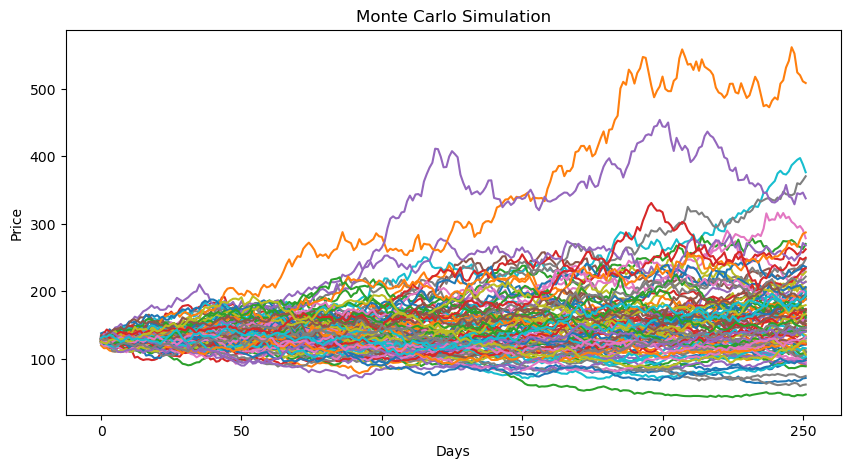

In [6]:
# Parameters
num_simulations = 100
num_days = 252

last_price = prices.iloc[-1]
mu = returns.mean()
sigma = returns.std()

simulations = np.zeros((num_days, num_simulations))

for i in range(num_simulations):
    price = last_price
    for t in range(num_days):
        shock = np.random.normal(mu, sigma)
        price = price * (1 + shock)
        simulations[t, i] = price

# Plot
plt.figure(figsize=(10,5))
plt.plot(simulations)
plt.title("Monte Carlo Simulation")
plt.xlabel("Days")
plt.ylabel("Price")
plt.show()